[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/digitalopentech/kaggle-huggingface/blob/main/hf-spaces/neurociencia-ecossistema/neurociencia-huggingface.ipynb)

# 🤗 Neurociência com o ecossistema Hugging Face

O Hugging Face Hub não é só para LLMs: é infraestrutura de **ciência aberta** — hospeda
datasets de EEG clínico, foundation models de sinais cerebrais e modelos de linguagem
biomédica. Este notebook percorre o ecossistema aplicado à neurociência, em quatro atos:

| Ato | Biblioteca | O que fazemos |
|---|---|---|
| 1 | `huggingface_hub` | O Hub como catálogo: buscar modelos e datasets de EEG via API |
| 2 | `huggingface_hub` + `mne` | Baixar EEG clínico real (CHB-MIT) e **visualizar uma crise epiléptica** |
| 3 | `braindecode` + `torch` | **EEGPT**, foundation model de EEG: embeddings pré-treinados de sinais cerebrais |
| 4 | `transformers` + `sentence-transformers` | Modelos de linguagem biomédica: fill-mask e mapa semântico da neurociência |

```bash
# dependências (no Colab, descomente a linha abaixo)
# !pip install -q huggingface_hub mne braindecode transformers sentence-transformers torch scikit-learn
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch, warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "lines.linewidth": 1.2,
})
AZUL, LARANJA, VERDE, ROSA = "#0072B2", "#D55E00", "#009E73", "#CC79A7"
np.random.seed(42); torch.manual_seed(42);

## Ato 1 — O Hub como catálogo científico

Tudo no Hub é acessível por API: dá para descobrir, filtrar e baixar programaticamente.

In [2]:
from huggingface_hub import HfApi

api = HfApi()
print("── Modelos de EEG mais baixados ──")
for m in api.list_models(search="eeg", sort="downloads", limit=5):
    print(f"  {m.id:45s} ↓{m.downloads:>6}")

print("\n── Datasets de EEG ──")
for d in api.list_datasets(search="eeg", sort="downloads", limit=5):
    print(f"  {d.id:45s} ↓{d.downloads:>6}")

── Modelos de EEG mais baixados ──


  braindecode/eegpt-pretrained                  ↓  3944
  braindecode/eegdino-medium-pretrained         ↓  1721
  braindecode/eegdino-small-pretrained          ↓  1159
  RichardErkhov/EEG123_-_subject2-test1-gguf    ↓   205
  mradermacher/Gemma-2-2B-it-16bit-eeg-fc-GGUF  ↓   159

── Datasets de EEG ──
  mirom11/eeg-veritas-results                   ↓  9601
  Haitao999/things-eeg                          ↓  5417
  LidongYang/EEG_Image_decode                   ↓  2546
  kgarg47/kahlus-raw-eeg-waveforms-efa0d90      ↓  2430
  opsecsystems/EEGWORLD                         ↓  1712


## Ato 2 — EEG clínico real: visualizando uma crise epiléptica

O **CHB-MIT** (Boston Children's Hospital / MIT) é o dataset clássico de epilepsia pediátrica:
EEG de escalpo contínuo com crises anotadas por neurologistas. Um espelho está no Hub — baixamos
**um arquivo EDF (42 MB)** com `hf_hub_download` (cacheado automaticamente) e lemos com `mne`.

No registro `chb01_03`, a anotação clínica marca uma crise entre **2996 s e 3036 s**.

In [3]:
from huggingface_hub import hf_hub_download
import mne
mne.set_log_level("ERROR")

REPO = "kgarg47/kahlus-raw-eeg-waveforms-efa0d90"
edf = hf_hub_download(REPO, "raw/chbmit/chb01/chb01_03.edf", repo_type="dataset")
raw = mne.io.read_raw_edf(edf, preload=False)
print(raw.info)
CRISE_INI, CRISE_FIM = 2996, 3036

raw/chbmit/chb01/chb01_03.edf: reconstructing file:   0%|          |  0.00B / 42.4MB            

raw/chbmit/chb01/chb01_03.edf: downloading bytes:           |  0.00B            

<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 13:43:04 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>


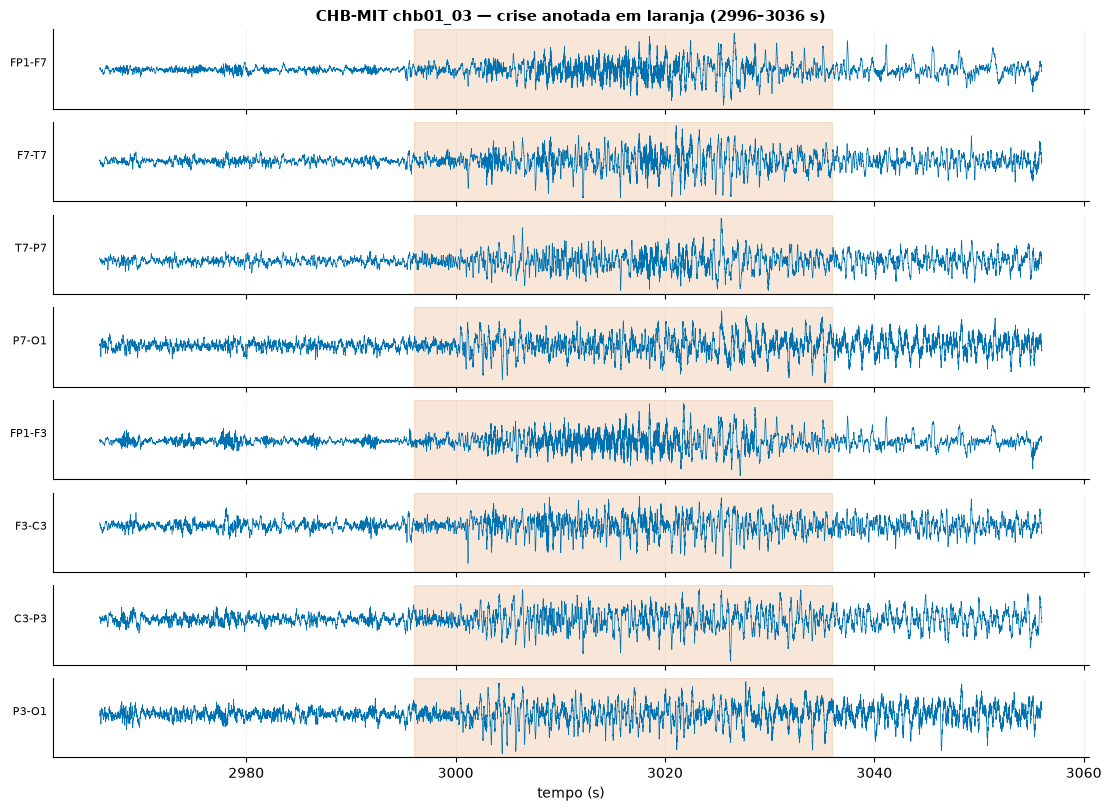

In [4]:
# 8 canais, de 30 s antes a 30 s depois do início da crise
canais = raw.ch_names[:8]
seg = raw.copy().pick(canais).crop(CRISE_INI - 30, CRISE_FIM + 20).load_data()
dados = seg.get_data() * 1e6                      # Volts -> µV
tempo = seg.times + (CRISE_INI - 30)

fig, axes = plt.subplots(len(canais), 1, figsize=(11, 8), sharex=True, constrained_layout=True)
for ax, sinal, nome in zip(axes, dados, canais):
    ax.plot(tempo, sinal, color=AZUL, lw=0.5)
    ax.axvspan(CRISE_INI, CRISE_FIM, color=LARANJA, alpha=0.15)
    ax.set_ylabel(nome, rotation=0, ha="right", fontsize=8)
    ax.set_yticks([])
axes[0].set_title("CHB-MIT chb01_03 — crise anotada em laranja (2996–3036 s)")
axes[-1].set_xlabel("tempo (s)");

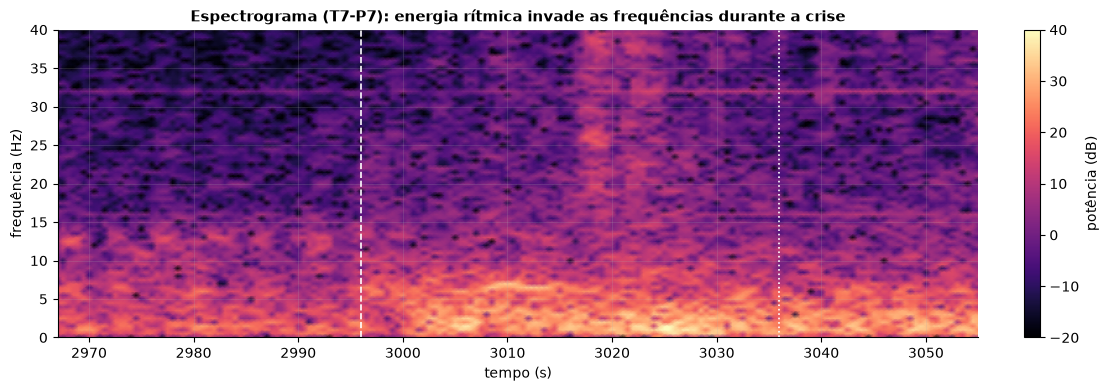

In [5]:
# Espectrograma de um canal: a assinatura tempo-frequência da crise
from scipy import signal as sps

canal = seg.get_data()[2] * 1e6
f_s, t_s, Sxx = sps.spectrogram(canal, fs=raw.info["sfreq"], nperseg=512, noverlap=384)

fig, ax = plt.subplots(figsize=(11, 3.8), constrained_layout=True)
pc = ax.pcolormesh(t_s + (CRISE_INI - 30), f_s, 10 * np.log10(Sxx + 1e-12),
                   cmap="magma", shading="gouraud", vmin=-20)
ax.axvline(CRISE_INI, color="white", ls="--", lw=1.2)
ax.axvline(CRISE_FIM, color="white", ls=":", lw=1.2)
ax.set_ylim(0, 40); ax.set_xlabel("tempo (s)"); ax.set_ylabel("frequência (Hz)")
ax.set_title(f"Espectrograma ({canais[2]}): energia rítmica invade as frequências durante a crise")
fig.colorbar(pc, label="potência (dB)");

## Ato 3 — EEGPT: um foundation model para EEG

O **EEGPT** (projeto [braindecode](https://braindecode.org)) é um transformer de 25M de
parâmetros **pré-treinado de forma auto-supervisionada** em grandes volumes de EEG — a mesma
receita dos LLMs, aplicada a sinais cerebrais. O checkpoint está no Hub e produz **embeddings
de 512 dimensões** por janela de 4 s (62 canais, 250 Hz).

> Nota técnica: o checkpoint foi salvo com a tabela de identidade de canais completa (62
> eletrodos do sistema 10-10); instanciamos com `chan_proj_type="none"` + o `chs_info` do
> `config.json` para casar a arquitetura, e carregamos os pesos do `model.safetensors`.
> Os 4 tensores ausentes são a cabeça de classificação — esperado num backbone pré-treinado.

In [6]:
import json
from braindecode.models import EEGPT
import safetensors.torch as st

cfg = json.load(open(hf_hub_download("braindecode/eegpt-pretrained", "config.json")))
eegpt = EEGPT(n_chans=cfg["n_chans"], n_times=cfg["n_times"], sfreq=cfg["sfreq"],
              n_outputs=cfg["n_outputs"], chs_info=cfg["chs_info"], chan_proj_type="none")
faltando, extras = st.load_model(
    eegpt, hf_hub_download("braindecode/eegpt-pretrained", "model.safetensors"), strict=False)
eegpt.eval()
print(f"EEGPT: {sum(p.numel() for p in eegpt.parameters())/1e6:.1f}M parâmetros | "
      f"pesos ausentes: {len(faltando)} (cabeça) | inesperados: {len(extras)}")

EEGPT: 25.3M parâmetros | pesos ausentes: 4 (cabeça) | inesperados: 0


### Os embeddings separam regimes cerebrais?

Geramos janelas sintéticas de 62 canais (4 s @ 250 Hz) em **quatro regimes eletrofisiológicos**
— ritmo alfa occipital (olhos fechados), beta frontal (atenção), espícula-onda a 3 Hz
(assinatura da crise de ausência) e artefato de movimento — e projetamos os embeddings do EEGPT
em 2D. *Dados sintéticos, de propósito: isolam a pergunta "o espaço de representação
pré-treinado organiza regimes de EEG?" sem confundidores de montagem.*

In [7]:
FS, T, N_CAN, N_JAN = 250, 4.0, 62, 40
t = np.arange(int(FS * T)) / FS
# gradientes espaciais aproximados (posição y dos eletrodos no config: frontal > 0 > occipital)
pos_y = np.array([c["loc"][1] for c in cfg["chs_info"]])
occipital = np.clip(-pos_y, 0, None) / np.abs(pos_y).max()
frontal   = np.clip(pos_y, 0, None) / np.abs(pos_y).max()

def ruido_rosa(n_can, n_amostras):
    esp = np.fft.rfft(np.random.randn(n_can, n_amostras))
    freqs = np.fft.rfftfreq(n_amostras, 1 / FS); freqs[0] = freqs[1]
    return np.fft.irfft(esp / np.sqrt(freqs), n=n_amostras)

def janela(regime):
    x = 4 * ruido_rosa(N_CAN, len(t))
    fase = np.random.rand() * 2 * np.pi
    if regime == "alfa (repouso)":
        x += 12 * occipital[:, None] * np.sin(2 * np.pi * 10 * t + fase)
    elif regime == "beta (atenção)":
        x += 8 * frontal[:, None] * np.sin(2 * np.pi * 21 * t + fase)
    elif regime == "espícula-onda 3 Hz":
        ciclo = np.sin(2 * np.pi * 3 * t + fase)
        x += 35 * (ciclo + 1.6 * np.clip(np.sin(2 * np.pi * 3 * t + fase + 0.4), 0.85, 1) ** 9)
    elif regime == "artefato":
        x += 60 * np.sin(2 * np.pi * 0.6 * t + fase) * (np.random.rand(N_CAN, 1) > 0.5)
    return x

REGIMES = ["alfa (repouso)", "beta (atenção)", "espícula-onda 3 Hz", "artefato"]
X = np.stack([janela(r) for r in REGIMES for _ in range(N_JAN)]).astype(np.float32)
y = np.repeat(np.arange(4), N_JAN)

with torch.no_grad():
    Z = []
    for lote in torch.split(torch.from_numpy(X), 16):
        z = eegpt.target_encoder(lote, eegpt.chans_id)   # (B, patches, tokens, 512)
        Z.append(z.mean(dim=(1, 2)))                      # média -> (B, 512)
    Z = torch.cat(Z).numpy()
print("embeddings:", Z.shape)

embeddings: (160, 512)


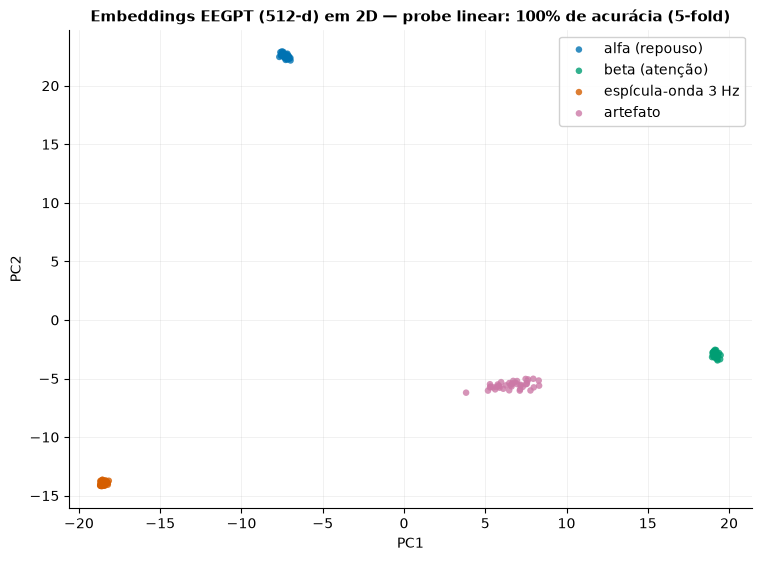

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

Zs = StandardScaler().fit_transform(Z)
p2 = PCA(n_components=2, random_state=42).fit_transform(Zs)
acc = cross_val_score(LogisticRegression(max_iter=2000), Zs, y, cv=5)

fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)
for k, (regime, cor) in enumerate(zip(REGIMES, [AZUL, VERDE, LARANJA, ROSA])):
    m = y == k
    ax.scatter(p2[m, 0], p2[m, 1], s=22, alpha=0.8, color=cor, label=regime, edgecolors="none")
ax.legend(framealpha=0.9)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"Embeddings EEGPT (512-d) em 2D — probe linear: {acc.mean():.0%} de acurácia (5-fold)");

Sem nenhum ajuste fino, o espaço de representação do EEGPT já organiza os regimes — é o
mesmo fenômeno que faz LLMs funcionarem como extratores de features, agora em eletrofisiologia.

## Ato 4 — Modelos de linguagem para o texto da neurociência

### 4a. Fill-mask com um BERT biomédico

O `BiomedBERT` (Microsoft) foi pré-treinado em abstracts do PubMed. Perguntamos a ele fatos
de neurociência por preenchimento de lacuna — conhecimento que emergiu só do pré-treino.

In [9]:
from transformers import pipeline

fm = pipeline("fill-mask", model="microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract")
frases = [
    "the hippocampus plays a critical role in [MASK] consolidation.",
    "epileptic seizures are caused by abnormal [MASK] activity in the brain.",
    "dopamine neurons in the ventral tegmental area encode reward [MASK] error.",
    "the [MASK] cortex is the primary region for processing visual information.",
    "long-term potentiation strengthens [MASK] connections between neurons.",
]
for frase in frases:
    top = fm(frase)[0]
    print(f"  [{top['score']:.2f}] {frase.replace('[MASK]', '__' + top['token_str'].upper() + '__')}")

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [0.99] the hippocampus plays a critical role in __MEMORY__ consolidation.
  [0.43] epileptic seizures are caused by abnormal __ELECTRICAL__ activity in the brain.
  [0.83] dopamine neurons in the ventral tegmental area encode reward __PREDICTION__ error.
  [0.39] the __VISUAL__ cortex is the primary region for processing visual information.


  [0.88] long-term potentiation strengthens __SYNAPTIC__ connections between neurons.


### 4b. O mapa semântico da neurociência com `sentence-transformers`

Embeddings de sentenças agrupam automaticamente tópicos de pesquisa — a base de sistemas RAG
e de organização de literatura científica.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

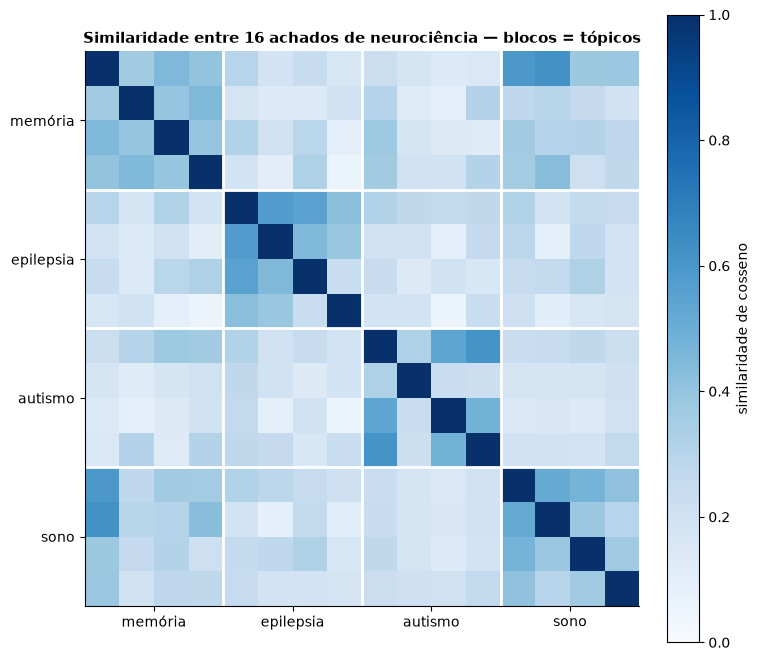

In [10]:
from sentence_transformers import SentenceTransformer

TOPICOS = {
    "memória":  ["hippocampal replay during sleep consolidates episodic memories",
                 "long-term potentiation is the synaptic basis of learning",
                 "place cells in the hippocampus encode spatial maps",
                 "the prefrontal cortex maintains information in working memory"],
    "epilepsia": ["interictal spikes predict seizure onset zones in focal epilepsy",
                  "absence seizures show generalized 3 Hz spike-and-wave discharges",
                  "EEG monitoring localizes the epileptogenic focus before surgery",
                  "sodium channel mutations cause Dravet syndrome epilepsy"],
    "autismo":  ["atypical functional connectivity characterizes the autistic brain",
                 "reduced fractional anisotropy in the corpus callosum in ASD",
                 "eye-tracking reveals atypical gaze patterns in autism",
                 "the excitation-inhibition balance hypothesis of autism"],
    "sono":     ["slow oscillations during deep sleep coordinate memory transfer",
                 "REM sleep supports emotional memory processing",
                 "sleep spindles gate sensory input to the thalamus",
                 "circadian rhythms are controlled by the suprachiasmatic nucleus"],
}
sentencas = [s for grupo in TOPICOS.values() for s in grupo]
modelo = SentenceTransformer("all-MiniLM-L6-v2")
emb = modelo.encode(sentencas)
sim = modelo.similarity(emb, emb).numpy()

fig, ax = plt.subplots(figsize=(7.5, 6.5), constrained_layout=True)
im = ax.imshow(sim, cmap="Blues", vmin=0.0, vmax=1.0)
ax.grid(False)
for i in range(1, 4):
    ax.axhline(4 * i - 0.5, color="white", lw=2); ax.axvline(4 * i - 0.5, color="white", lw=2)
ax.set_xticks([1.5, 5.5, 9.5, 13.5], list(TOPICOS)); ax.set_yticks([1.5, 5.5, 9.5, 13.5], list(TOPICOS))
ax.set_title("Similaridade entre 16 achados de neurociência — blocos = tópicos")
fig.colorbar(im, label="similaridade de cosseno");

## Conclusões

- O Hub funciona como **infraestrutura de neurociência aberta**: dados clínicos (CHB-MIT),
  foundation models de EEG (EEGPT) e modelos de linguagem biomédica, tudo versionado e acessível
  por API.
- O paradigma dos foundation models chegou à eletrofisiologia: embeddings pré-treinados de EEG
  já organizam regimes cerebrais sem ajuste fino — transfer learning para neurociência clínica.
- As mesmas quatro bibliotecas (`huggingface_hub`, `braindecode`, `transformers`,
  `sentence-transformers`) cobrem o ciclo completo: dados → sinal → representação → literatura.

### Nesta série
- ⚡ [Potencial de ação — Hodgkin-Huxley](https://huggingface.co/spaces/leonardovalle/hodgkin-huxley-potencial-de-acao) (Space)
- 🧩 [Neurociência do TEA](https://www.kaggle.com/code/leonardonunesrj/neuroci-ncia-do-tea-triagem-e-conectividade) (Kaggle)
- 🧰 [Repositório completo](https://github.com/digitalopentech/kaggle-huggingface) (GitHub)

### Referências
- Shoeb, A. (2009). *CHB-MIT Scalp EEG Database.* PhysioNet.
- Wang et al. (2024). *EEGPT: Pretrained Transformer for Universal and Reliable Representation
  of EEG Signals.* NeurIPS.
- Gu et al. (2021). *Domain-Specific Language Model Pretraining for Biomedical NLP.* ACM HEALTH.